In [1]:
import sys
print(sys.version)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


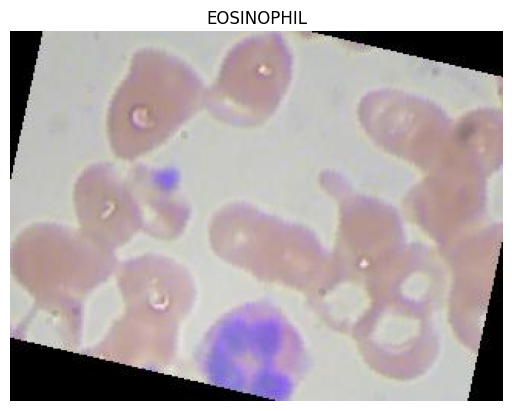

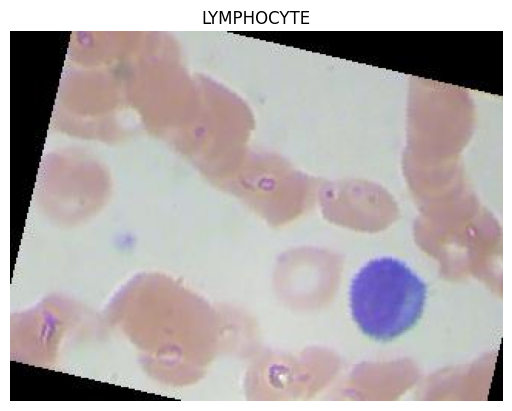

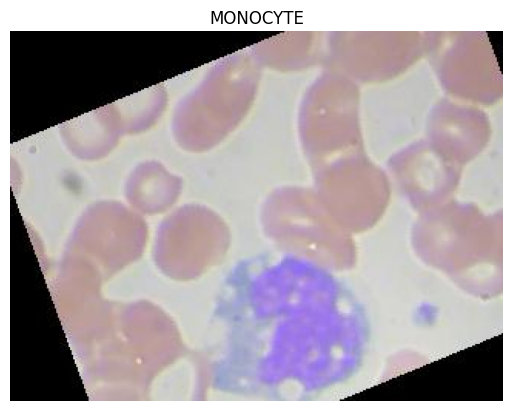

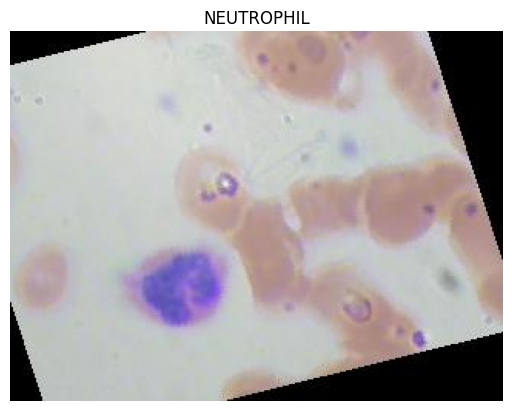

In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Correct path
dataset_path = "../dataset"

classes = os.listdir(dataset_path)
print("Classes:", classes)

for category in classes:
    folder = os.path.join(dataset_path, category)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)

    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')
    plt.show()

In [3]:
import os
import numpy as np
from PIL import Image

# Dataset path
dataset_path = "../dataset"

IMG_SIZE = 224

data = []
labels = []

class_names = os.listdir(dataset_path)

print("Processing images...")

for label, category in enumerate(class_names):
    folder = os.path.join(dataset_path, category)
    
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        
        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            
            img_array = np.array(img)
            
            data.append(img_array)
            labels.append(label)
            
        except Exception as e:
            print("Skipping:", img_path)

# Convert to numpy arrays
X = np.array(data)
y = np.array(labels)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)

Processing images...
Data shape: (2487, 224, 224, 3)
Labels shape: (2487,)


In [4]:
X = X / 255.0
print("Normalized Data:", X[0][0][0])

Normalized Data: [0. 0. 0.]


In [5]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y, num_classes=len(class_names))

print("After one-hot encoding:", y[0])

After one-hot encoding: [1. 0. 0. 0.]


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1989, 224, 224, 3)
Test shape: (498, 224, 224, 3)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

# Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4, activation='softmax'))  # 4 classes

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\samri\OneDrive\Desktop\Hematovision Prediction\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 487ms/step - accuracy: 0.3374 - loss: 1.5147 - val_accuracy: 0.4679 - val_loss: 1.2441
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 440ms/step - accuracy: 0.4766 - loss: 1.1792 - val_accuracy: 0.5321 - val_loss: 1.0759
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 442ms/step - accuracy: 0.5551 - loss: 1.0440 - val_accuracy: 0.5783 - val_loss: 0.9867
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 409ms/step - accuracy: 0.6109 - loss: 0.9169 - val_accuracy: 0.6165 - val_loss: 0.9017
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 408ms/step - accuracy: 0.6536 - loss: 0.8128 - val_accuracy: 0.6265 - val_loss: 0.8741
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 407ms/step - accuracy: 0.7099 - loss: 0.7111 - val_accuracy: 0.6526 - val_loss: 0.7976
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 405ms/step - accuracy: 0.7521 - loss: 0.6190 - val_accuracy: 0.6325 - val_loss: 0.8221
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 422ms/step - accuracy: 0.7722 - loss: 0.5695 - val_accu

In [9]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.6687 - loss: 0.8195
Test Accuracy: 0.6686747074127197


In [10]:
model.save("../model/blood_cell_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [14]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image

folder = "../dataset/EOSINOPHIL"

# automatically pick first image
img_name = os.listdir(folder)[0]
img_path = os.path.join(folder, img_name)

print("Using image:", img_path)

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

prediction = model.predict(img_array)

class_names = ['EOSINOPHIL','LYMPHOCYTE','MONOCYTE','NEUTROPHIL']

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

Using image: ../dataset/EOSINOPHIL\_0_1616.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Predicted Class: EOSINOPHIL


In [13]:
import os

print(os.listdir("../dataset/EOSINOPHIL"))

['_0_1616.jpeg', '_0_1794.jpeg', '_0_1845.jpeg', '_0_187.jpeg', '_0_196.jpeg', '_0_2107.jpeg', '_0_2183.jpeg', '_0_2313.jpeg', '_0_2498.jpeg', '_0_2634.jpeg', '_0_2789.jpeg', '_0_2963.jpeg', '_0_3083.jpeg', '_0_3249.jpeg', '_0_3809.jpeg', '_0_3859.jpeg', '_0_4055.jpeg', '_0_4130.jpeg', '_0_463.jpeg', '_0_5642.jpeg', '_0_5709.jpeg', '_0_5733.jpeg', '_0_586.jpeg', '_0_5974.jpeg', '_0_5988.jpeg', '_0_6052.jpeg', '_0_6243.jpeg', '_0_6354.jpeg', '_0_6878.jpeg', '_0_737.jpeg', '_0_7604.jpeg', '_0_7764.jpeg', '_0_7845.jpeg', '_0_8167.jpeg', '_0_8201.jpeg', '_0_8222.jpeg', '_0_8254.jpeg', '_0_8473.jpeg', '_0_852.jpeg', '_0_8611.jpeg', '_0_8718.jpeg', '_0_8829.jpeg', '_0_884.jpeg', '_0_8881.jpeg', '_0_9294.jpeg', '_0_9620.jpeg', '_0_967.jpeg', '_0_9763.jpeg', '_0_9876.jpeg', '_10_1104.jpeg', '_10_1367.jpeg', '_10_1626.jpeg', '_10_1830.jpeg', '_10_2029.jpeg', '_10_2539.jpeg', '_10_2893.jpeg', '_10_2897.jpeg', '_10_2988.jpeg', '_10_3313.jpeg', '_10_3363.jpeg', '_10_3818.jpeg', '_10_4000.jpeg', '_